# First step

## Load all necessary Libraries 


In [1]:
# Import necessary libraries

# Basic libraries for numerical operations, data manipulation, and visualization
import numpy as np  # For numerical computations
import pandas as pd  # For data manipulation and analysis
import seaborn as sns  # For statistical data visualization
import matplotlib.pyplot as plt  # For creating plots and figures
import warnings  # To handle warnings in the code
warnings.filterwarnings('ignore')  # Ignore warnings to reduce clutter

# Data Preprocessing and Feature Scaling
from sklearn.preprocessing import StandardScaler, MinMaxScaler  # For feature scaling (Standard and Min-Max scaling)

# Data Splitting and Model Evaluation
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV,cross_validate  # For splitting data, cross-validation, and hyperparameter tuning
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix  # For model evaluation and performance metrics

# Handling Imbalanced Datasets
from imblearn.over_sampling import SMOTE  # For handling imbalanced datasets

# Machine Learning Models (for classification)
from sklearn.linear_model import LogisticRegression  # Logistic Regression for binary classification
from sklearn.neural_network import MLPClassifier  # Multi-layer Perceptron (Neural Network) for classification
from sklearn.svm import SVC  # Support Vector Machine classifier
from sklearn.ensemble import (
    RandomForestClassifier,  # Random Forest classifier
    GradientBoostingClassifier,  # Gradient Boosting classifier
    AdaBoostClassifier,  # AdaBoost classifier
    ExtraTreesClassifier,
    StackingClassifier,  # Stacking classifier
    VotingClassifier  # Voting classifier
)
from xgboost import XGBClassifier  # XGBoost classifier

# Model Interpretability (SHAP)
import shap

In [2]:
df = pd.read_csv('CVDS_dataset.csv')

In [3]:
df.head()

,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,HadHeartAttack,HadAngina,HadStroke,...,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,SystolicBP,DiastolicBP,Cholesterol,PrematureFamilyHistory
0,Female,Very good,4,0,Within past year (anytime less than 12 months ...,Yes,9,No,No,No,...,No,Yes,Yes,"Yes, received Tdap",No,No,108,73,189,No
1,Male,Very good,0,0,Within past year (anytime less than 12 months ...,Yes,6,No,No,No,...,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No,147,95,236,Yes
2,Male,Very good,0,0,Within past year (anytime less than 12 months ...,No,8,No,No,No,...,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes,124,65,202,No
3,Female,Fair,5,0,Within past year (anytime less than 12 months ...,Yes,9,No,No,No,...,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes,115,80,186,No
4,Female,Good,3,15,Within past year (anytime less than 12 months ...,Yes,5,No,No,No,...,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No,123,82,207,No


In [4]:
# Check unique values in the "Smoker Status" column
smoker_status_unique = df['SmokerStatus'].unique()

# Print the unique values for Smoker Status
print("Unique values in Smoker Status:", smoker_status_unique)

Unique values in Smoker Status: ['Former smoker' 'Never smoked' 'Current smoker - now smokes every day'
 'Current smoker - now smokes some days']


In [5]:
# Check unique values in the "Smoker Status" column
LastCheckupTime_unique = df['LastCheckupTime'].unique()

# Print the unique values for Smoker Status
print("Unique values in LastCheckupTime:", LastCheckupTime_unique)

Unique values in LastCheckupTime: ['Within past year (anytime less than 12 months ago)'
 '5 or more years ago'
 'Within past 2 years (1 year but less than 2 years ago)'
 'Within past 5 years (2 years but less than 5 years ago)']


In [6]:
df.columns

Index(['Sex', 'GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays',
       'LastCheckupTime', 'PhysicalActivities', 'SleepHours', 'HadHeartAttack',
       'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD',
       'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis',
       'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty',
       'DifficultyConcentrating', 'DifficultyWalking',
       'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus',
       'ChestScan', 'AgeCategory', 'BMI', 'AlcoholDrinkers', 'HIVTesting',
       'FluVaxLast12', 'PneumoVaxEver', 'TetanusLast10Tdap',
       'HighRiskLastYear', 'CovidPos', 'SystolicBP', 'DiastolicBP',
       'Cholesterol', 'PrematureFamilyHistory'],
      dtype='object')

## Check Duplicate 

In [7]:
df.duplicated().sum()

0

In [8]:
duplicate_count = df.duplicated().sum()  # Total duplicate rows
print(f"Total duplicate rows: {duplicate_count}")


Total duplicate rows: 0


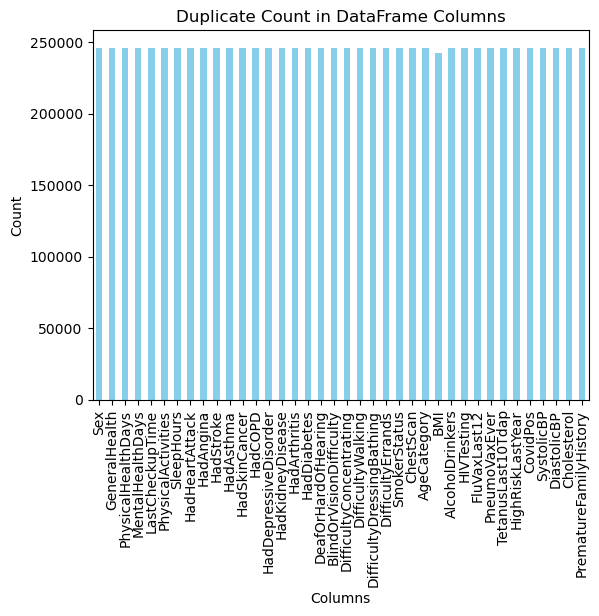

<Figure size 640x480 with 0 Axes>

In [9]:
import os
folder_path = 'output_images'
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
duplicate_per_column = df.apply(lambda x: x.duplicated().sum())
duplicate_per_column.plot(kind='bar', color='skyblue')

plt.title('Duplicate Count in DataFrame Columns')
plt.ylabel('Count')
plt.xlabel('Columns')
plt.xticks(rotation=90)
plt.show()
# Save the plot as an image
image_path = os.path.join(folder_path, 'Duplicate Count in DataFrame Columns')
plt.savefig(image_path)


## Remove the duplicate

Duplicates negatively impact model performance by introducing bias, increasing overfitting, and skewing results.

In [10]:
df.drop_duplicates(inplace = True)

In [11]:
df.describe()

,PhysicalHealthDays,MentalHealthDays,SleepHours,BMI,SystolicBP,DiastolicBP,Cholesterol
count,246022.000000,246022.000000,246022.000000,246022.000000,246022.000000,246022.000000,246022.000000
mean,4.119026,4.167140,7.021331,28.668136,119.889067,76.552971,192.858289
std,8.405844,8.102687,1.440681,6.513973,13.645546,9.418668,24.403714
min,0.000000,0.000000,1.000000,12.020000,95.000000,57.000000,140.000000
25%,0.000000,0.000000,6.000000,24.270000,110.000000,70.000000,175.000000
50%,0.000000,0.000000,7.000000,27.460000,117.000000,76.000000,191.000000
75%,3.000000,4.000000,8.000000,31.890000,127.000000,82.000000,209.000000
max,30.000000,30.000000,24.000000,97.650000,164.000000,102.000000,269.000000


### Check Missing Values

In [12]:
df.isnull().sum()

Sex                          0
GeneralHealth                0
PhysicalHealthDays           0
MentalHealthDays             0
LastCheckupTime              0
PhysicalActivities           0
SleepHours                   0
HadHeartAttack               0
HadAngina                    0
HadStroke                    0
HadAsthma                    0
HadSkinCancer                0
HadCOPD                      0
HadDepressiveDisorder        0
HadKidneyDisease             0
HadArthritis                 0
HadDiabetes                  0
DeafOrHardOfHearing          0
BlindOrVisionDifficulty      0
DifficultyConcentrating      0
DifficultyWalking            0
DifficultyDressingBathing    0
DifficultyErrands            0
SmokerStatus                 0
ChestScan                    0
AgeCategory                  0
BMI                          0
AlcoholDrinkers              0
HIVTesting                   0
FluVaxLast12                 0
PneumoVaxEver                0
TetanusLast10Tdap            0
HighRisk

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import os


# Get the null count for each column
null_count = df.isnull().sum()

# Create a bar plot of the null values count
plt.figure(figsize=(10, 6))
null_count.plot(kind='bar', color='skyblue')

# Set the title and labels
plt.title('Missing Values Count in DataFrame Columns')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')

# Create the folder to save the image if it doesn't exist
folder_path = 'output_images'
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# Save the plot as an image
image_path = os.path.join(folder_path, 'missing_values_count.png')
plt.savefig(image_path)

# Close the plot to avoid display in interactive environments
plt.close()

print(f"Image saved to {image_path}")


Image saved to output_images\missing_values_count.png


It seems there are no missing values, but that's not true. Let's use a visualization method to verify this.


## Visualization of Qualitative and Quantitative Datasets

In [14]:
# Let us first distingush datasets into num and object
num = []
cat = []
for i,col in enumerate(df.columns):
    if df[col].nunique() > 5:
        num.append(col)
    else:
        cat.append(col)
        df[col] = df[col].astype('object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246022 entries, 0 to 246021
Data columns (total 38 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Sex                        246022 non-null  object 
 1   GeneralHealth              246022 non-null  object 
 2   PhysicalHealthDays         246022 non-null  int64  
 3   MentalHealthDays           246022 non-null  int64  
 4   LastCheckupTime            246022 non-null  object 
 5   PhysicalActivities         246022 non-null  object 
 6   SleepHours                 246022 non-null  int64  
 7   HadHeartAttack             246022 non-null  object 
 8   HadAngina                  246022 non-null  object 
 9   HadStroke                  246022 non-null  object 
 10  HadAsthma                  246022 non-null  object 
 11  HadSkinCancer              246022 non-null  object 
 12  HadCOPD                    246022 non-null  object 
 13  HadDepressiveDisorder      24

#### now we can select the numerical features and catergorical features

In [16]:
cat = df[cat]

In [17]:
num = df[num]

In [18]:
cat.drop('HadHeartAttack',axis =1, inplace = True)

In [19]:
cat

,Sex,GeneralHealth,LastCheckupTime,PhysicalActivities,HadAngina,HadStroke,HadAsthma,HadSkinCancer,HadCOPD,HadDepressiveDisorder,...,SmokerStatus,ChestScan,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,PrematureFamilyHistory
0,Female,Very good,Within past year (anytime less than 12 months ...,Yes,No,No,No,No,No,No,...,Former smoker,No,No,No,Yes,Yes,"Yes, received Tdap",No,No,No
1,Male,Very good,Within past year (anytime less than 12 months ...,Yes,No,No,No,No,No,No,...,Former smoker,No,No,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No,Yes
2,Male,Very good,Within past year (anytime less than 12 months ...,No,No,No,No,No,No,No,...,Former smoker,Yes,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes,No
3,Female,Fair,Within past year (anytime less than 12 months ...,Yes,No,No,No,Yes,No,Yes,...,Never smoked,No,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes,No
4,Female,Good,Within past year (anytime less than 12 months ...,Yes,No,No,No,No,No,No,...,Never smoked,No,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246017,Male,Very good,Within past 2 years (1 year but less than 2 ye...,Yes,No,No,No,No,No,No,...,Never smoked,No,Yes,No,No,No,"Yes, received tetanus shot but not sure what type",No,No,Yes
246018,Female,Fair,Within past year (anytime less than 12 months ...,Yes,No,No,No,No,No,Yes,...,Never smoked,No,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,Yes,Yes
246019,Male,Good,Within past year (anytime less than 12 months ...,Yes,No,Yes,No,No,No,No,...,Never smoked,No,Yes,Yes,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,Yes,Yes
246020,Female,Excellent,Within past year (anytime less than 12 months ...,Yes,No,No,No,No,No,No,...,Never smoked,No,No,Yes,Yes,No,"Yes, received tetanus shot but not sure what type",No,No,No


In [20]:
cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246022 entries, 0 to 246021
Data columns (total 29 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   Sex                        246022 non-null  object
 1   GeneralHealth              246022 non-null  object
 2   LastCheckupTime            246022 non-null  object
 3   PhysicalActivities         246022 non-null  object
 4   HadAngina                  246022 non-null  object
 5   HadStroke                  246022 non-null  object
 6   HadAsthma                  246022 non-null  object
 7   HadSkinCancer              246022 non-null  object
 8   HadCOPD                    246022 non-null  object
 9   HadDepressiveDisorder      246022 non-null  object
 10  HadKidneyDisease           246022 non-null  object
 11  HadArthritis               246022 non-null  object
 12  HadDiabetes                246022 non-null  object
 13  DeafOrHardOfHearing        246022 non-null  

In [21]:
num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246022 entries, 0 to 246021
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   PhysicalHealthDays  246022 non-null  int64  
 1   MentalHealthDays    246022 non-null  int64  
 2   SleepHours          246022 non-null  int64  
 3   AgeCategory         246022 non-null  object 
 4   BMI                 246022 non-null  float64
 5   SystolicBP          246022 non-null  int64  
 6   DiastolicBP         246022 non-null  int64  
 7   Cholesterol         246022 non-null  int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 15.0+ MB


In [22]:
num

,PhysicalHealthDays,MentalHealthDays,SleepHours,AgeCategory,BMI,SystolicBP,DiastolicBP,Cholesterol
0,4,0,9,Age 65 to 69,27.99,108,73,189
1,0,0,6,Age 70 to 74,30.13,147,95,236
2,0,0,8,Age 75 to 79,31.66,124,65,202
3,5,0,9,Age 80 or older,31.32,115,80,186
4,3,15,5,Age 80 or older,33.07,123,82,207
...,...,...,...,...,...,...,...,...
246017,0,0,6,Age 60 to 64,32.28,122,67,208
246018,0,7,7,Age 25 to 29,24.34,125,73,185
246019,0,15,7,Age 65 to 69,29.86,157,95,254
246020,2,2,7,Age 50 to 54,28.66,110,78,160


In [23]:
cat_features = df.select_dtypes('object').drop('HadHeartAttack',axis = 1)
num_features = df.select_dtypes('number')

In [24]:
cat_features

,Sex,GeneralHealth,LastCheckupTime,PhysicalActivities,HadAngina,HadStroke,HadAsthma,HadSkinCancer,HadCOPD,HadDepressiveDisorder,...,ChestScan,AgeCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,PrematureFamilyHistory
0,Female,Very good,Within past year (anytime less than 12 months ...,Yes,No,No,No,No,No,No,...,No,Age 65 to 69,No,No,Yes,Yes,"Yes, received Tdap",No,No,No
1,Male,Very good,Within past year (anytime less than 12 months ...,Yes,No,No,No,No,No,No,...,No,Age 70 to 74,No,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No,Yes
2,Male,Very good,Within past year (anytime less than 12 months ...,No,No,No,No,No,No,No,...,Yes,Age 75 to 79,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes,No
3,Female,Fair,Within past year (anytime less than 12 months ...,Yes,No,No,No,Yes,No,Yes,...,No,Age 80 or older,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes,No
4,Female,Good,Within past year (anytime less than 12 months ...,Yes,No,No,No,No,No,No,...,No,Age 80 or older,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246017,Male,Very good,Within past 2 years (1 year but less than 2 ye...,Yes,No,No,No,No,No,No,...,No,Age 60 to 64,Yes,No,No,No,"Yes, received tetanus shot but not sure what type",No,No,Yes
246018,Female,Fair,Within past year (anytime less than 12 months ...,Yes,No,No,No,No,No,Yes,...,No,Age 25 to 29,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,Yes,Yes
246019,Male,Good,Within past year (anytime less than 12 months ...,Yes,No,Yes,No,No,No,No,...,No,Age 65 to 69,Yes,Yes,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,Yes,Yes
246020,Female,Excellent,Within past year (anytime less than 12 months ...,Yes,No,No,No,No,No,No,...,No,Age 50 to 54,No,Yes,Yes,No,"Yes, received tetanus shot but not sure what type",No,No,No


### Scale numerical feature

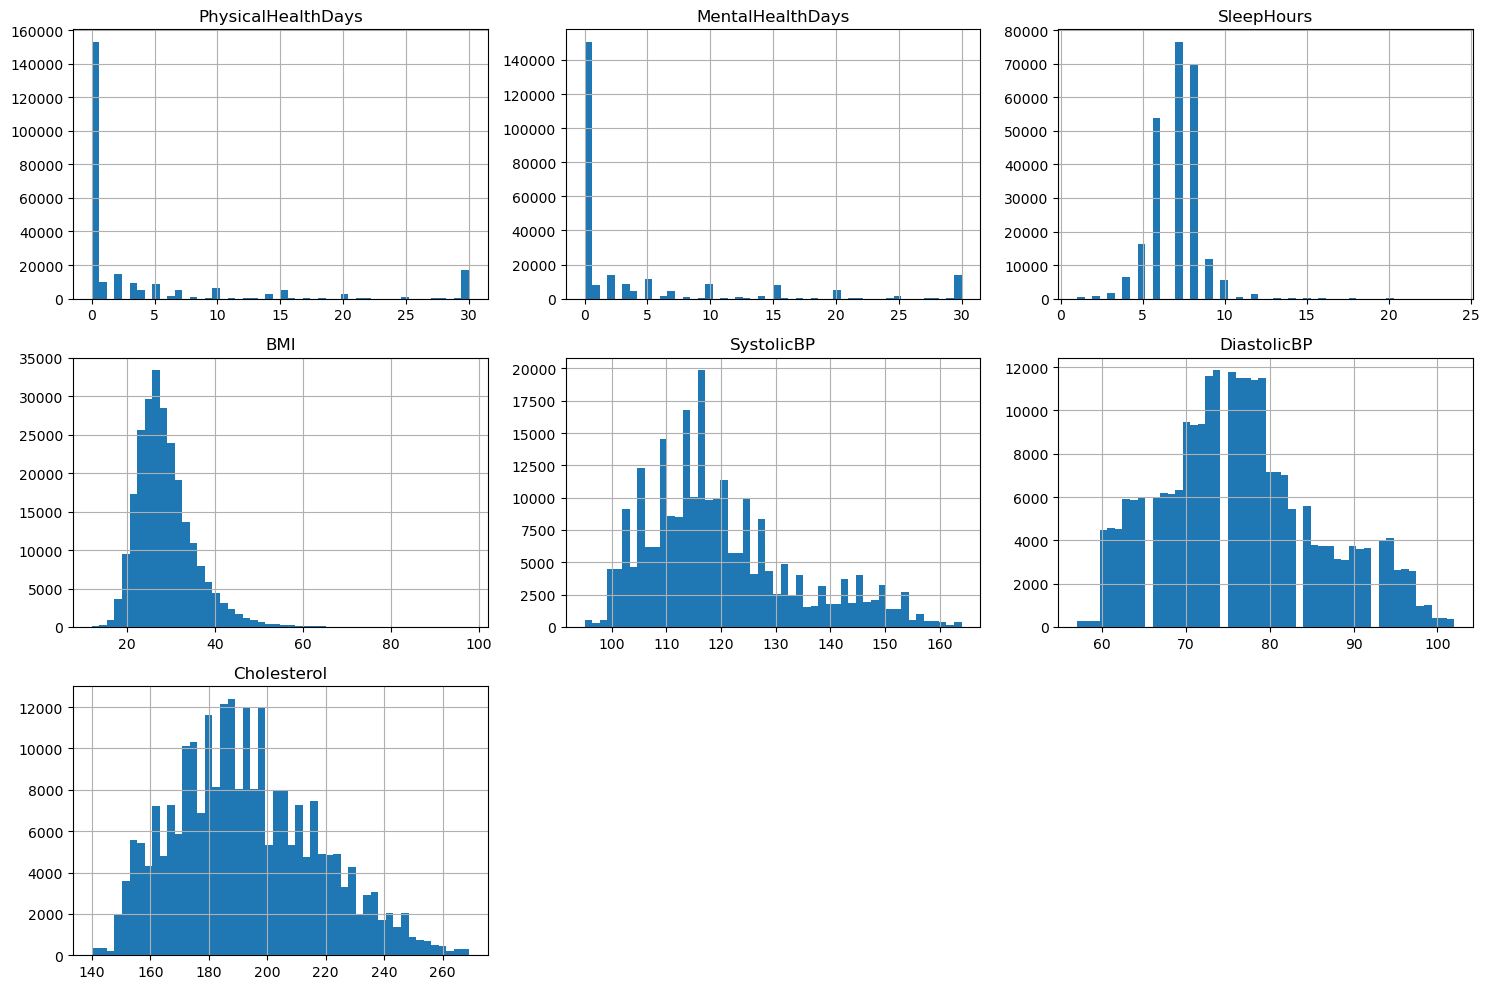

In [25]:
import matplotlib.pyplot as plt

# Generate histograms for numeric columns
df.select_dtypes(['float', 'int']).hist(bins=50, figsize=(15, 10))

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the figure to a file
plt.savefig('histogram_output.png')  # You can change the filename and format as needed

# Display the plot
plt.show()


<Figure size 2000x600 with 0 Axes>

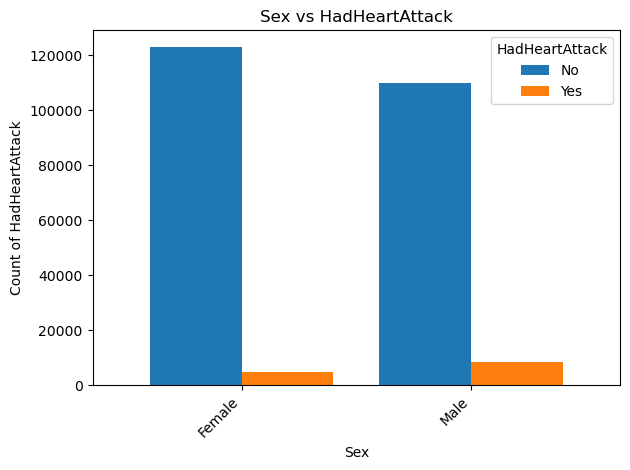

<Figure size 2000x600 with 0 Axes>

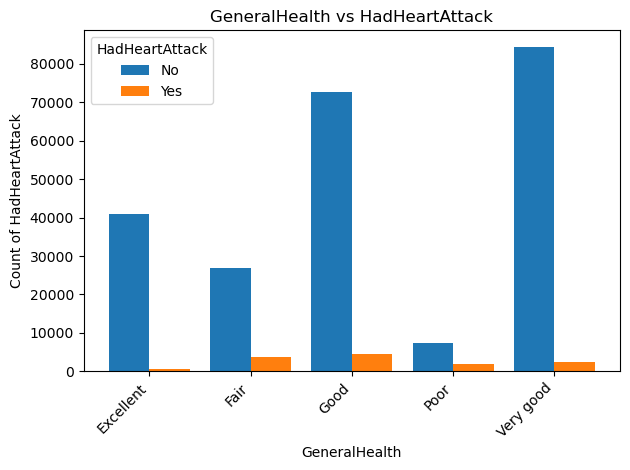

<Figure size 2000x600 with 0 Axes>

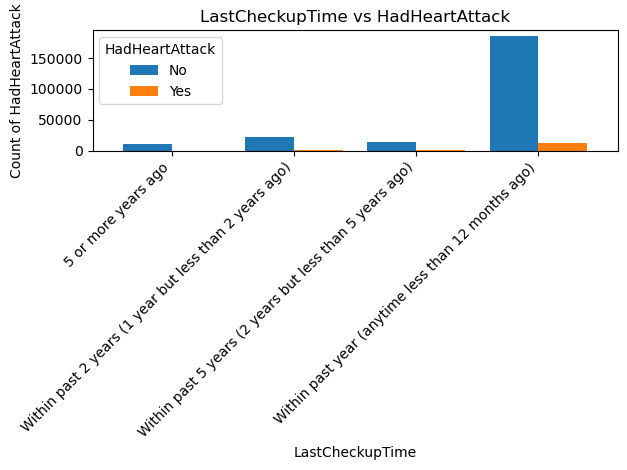

<Figure size 2000x600 with 0 Axes>

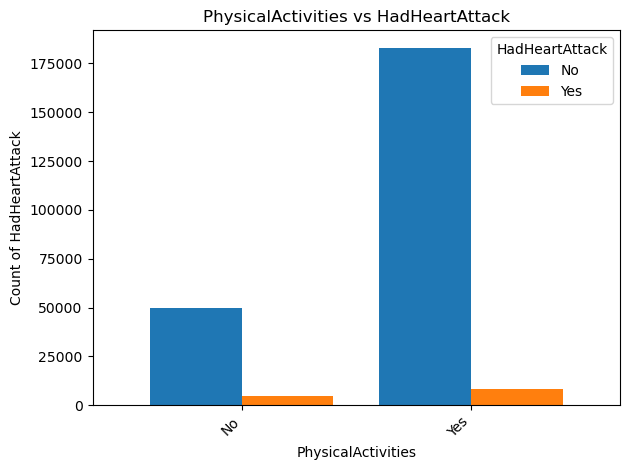

<Figure size 2000x600 with 0 Axes>

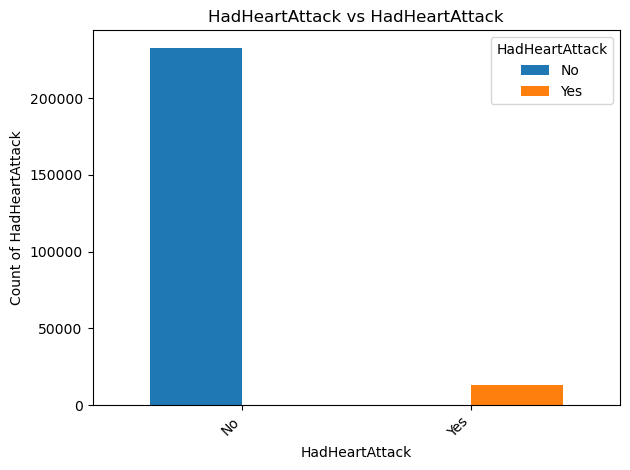

<Figure size 2000x600 with 0 Axes>

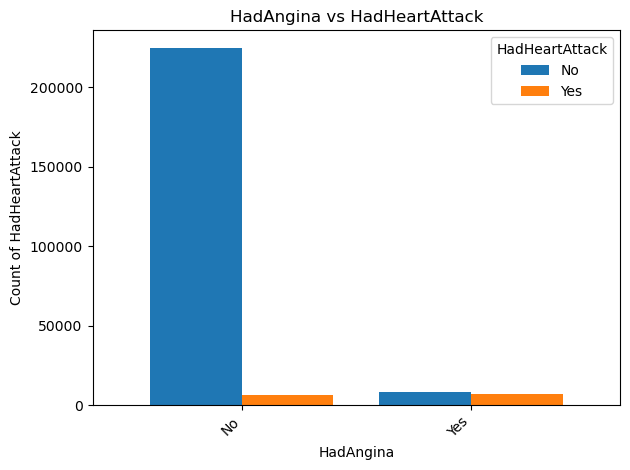

<Figure size 2000x600 with 0 Axes>

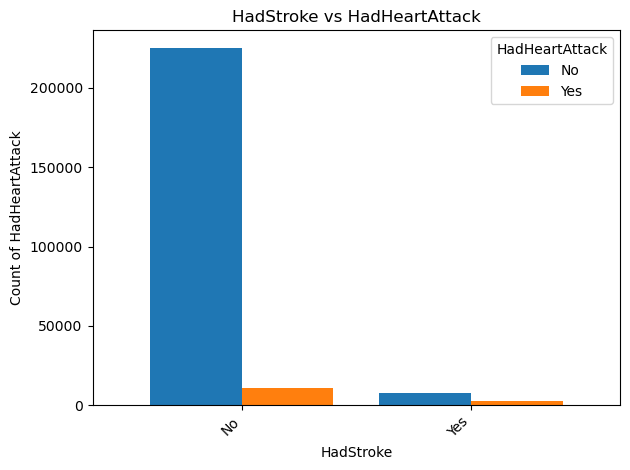

<Figure size 2000x600 with 0 Axes>

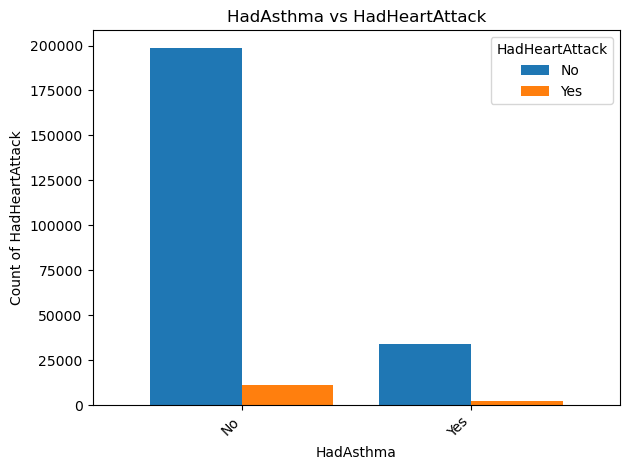

<Figure size 2000x600 with 0 Axes>

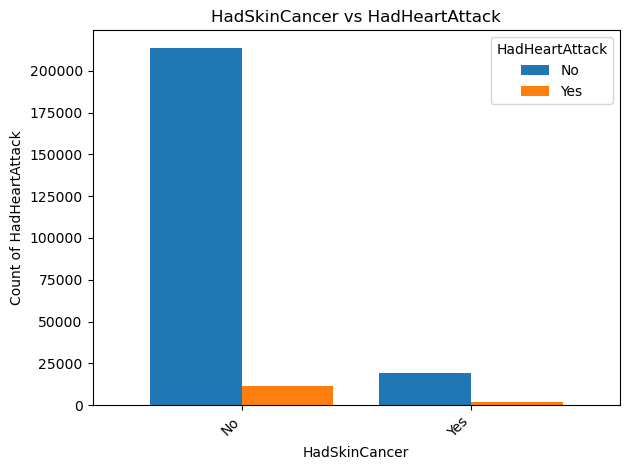

<Figure size 2000x600 with 0 Axes>

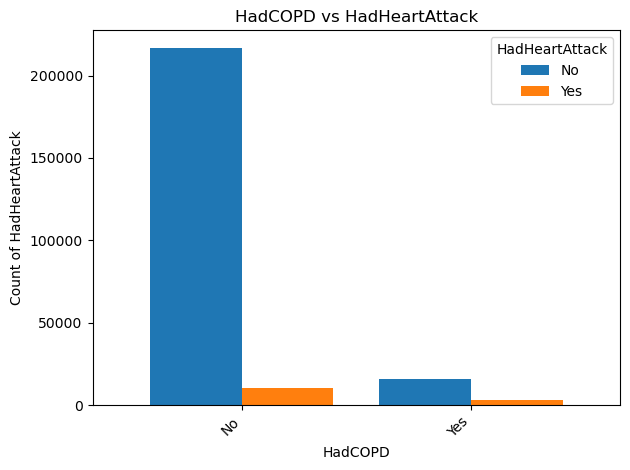

<Figure size 2000x600 with 0 Axes>

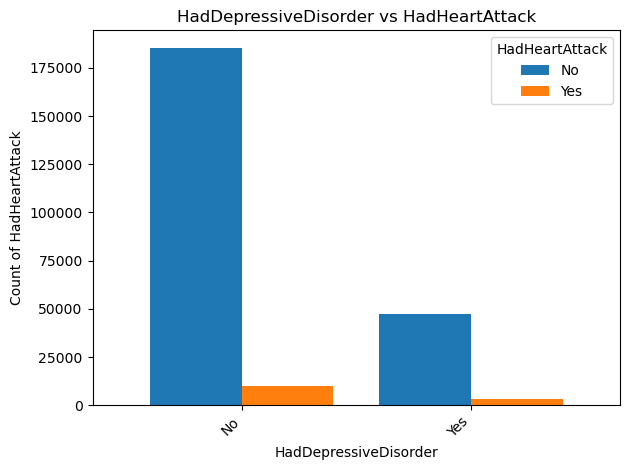

<Figure size 2000x600 with 0 Axes>

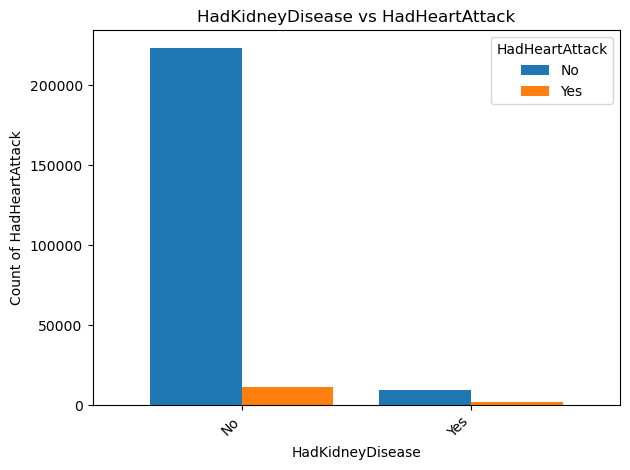

<Figure size 2000x600 with 0 Axes>

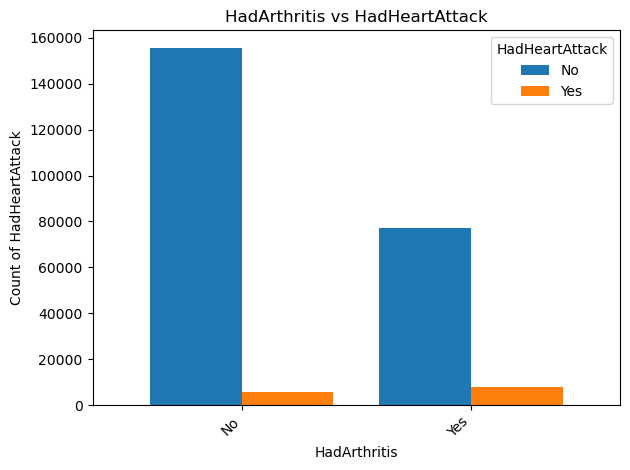

<Figure size 2000x600 with 0 Axes>

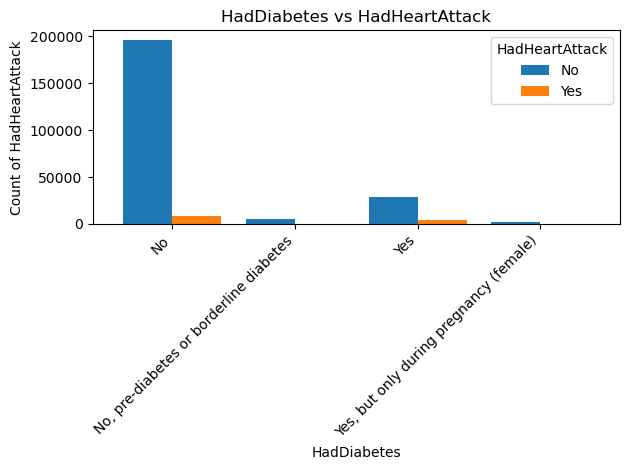

<Figure size 2000x600 with 0 Axes>

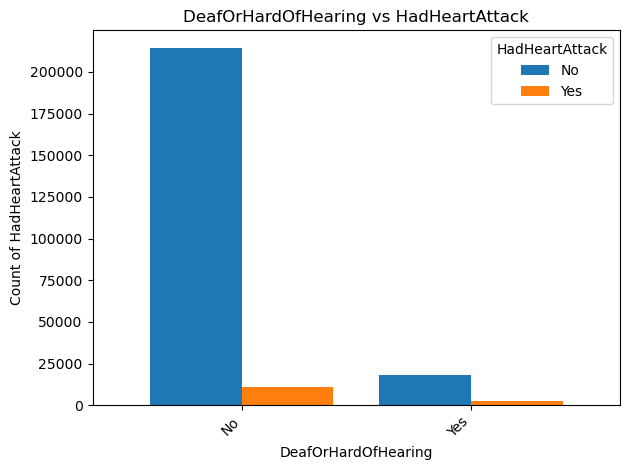

<Figure size 2000x600 with 0 Axes>

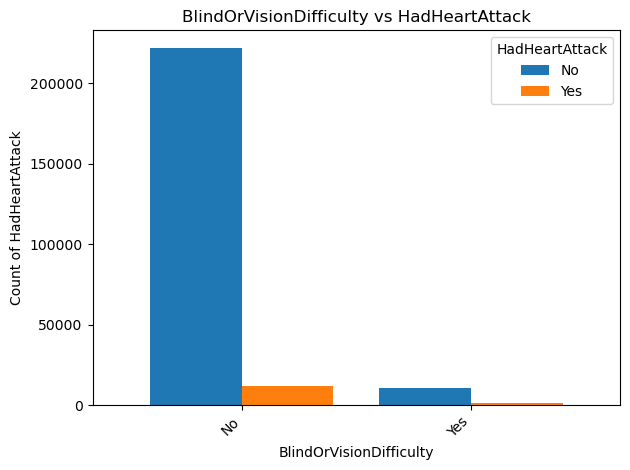

<Figure size 2000x600 with 0 Axes>

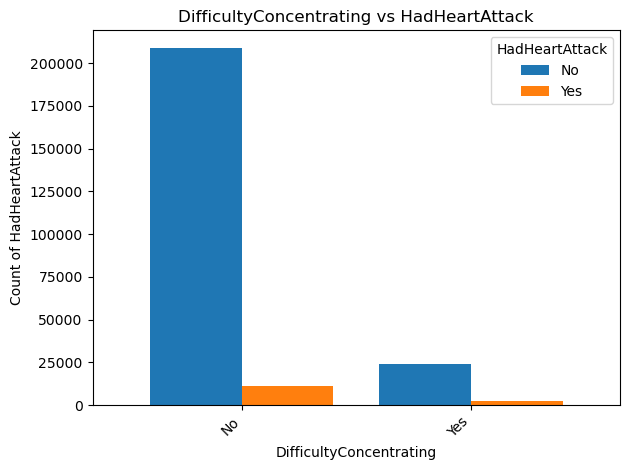

<Figure size 2000x600 with 0 Axes>

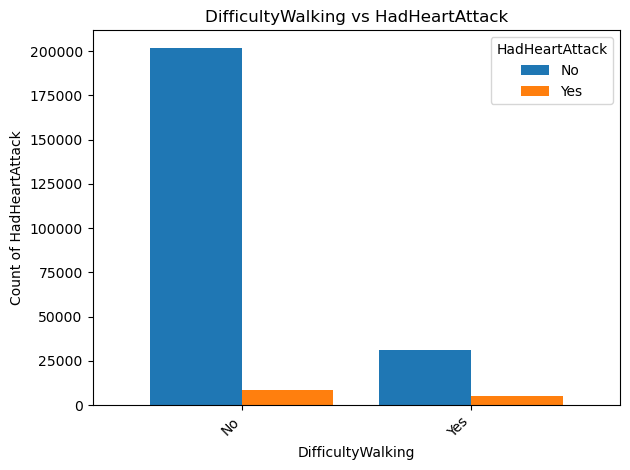

<Figure size 2000x600 with 0 Axes>

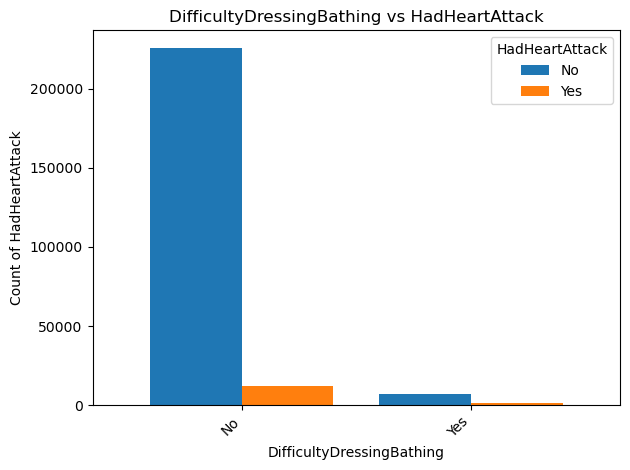

<Figure size 2000x600 with 0 Axes>

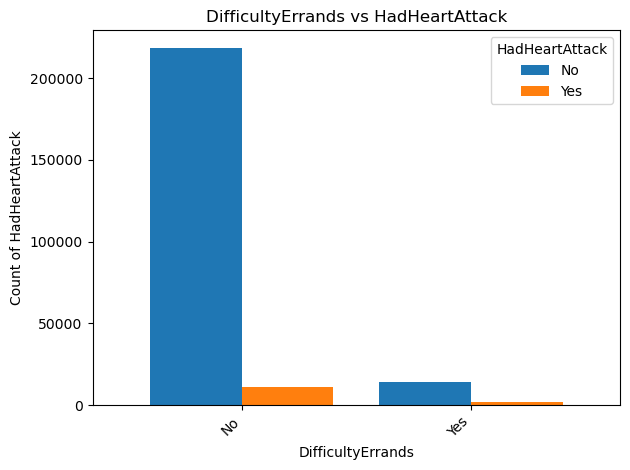

<Figure size 2000x600 with 0 Axes>

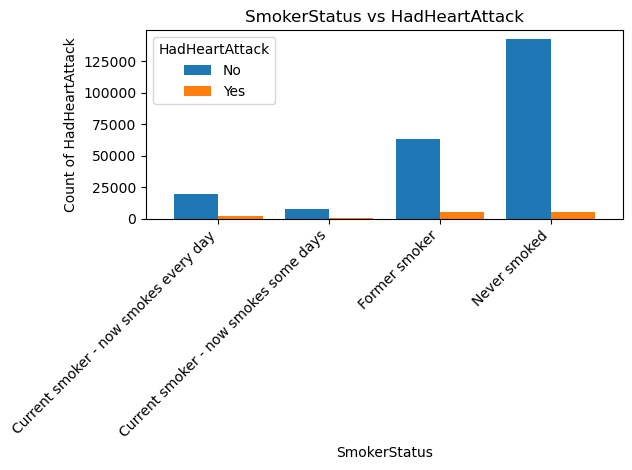

<Figure size 2000x600 with 0 Axes>

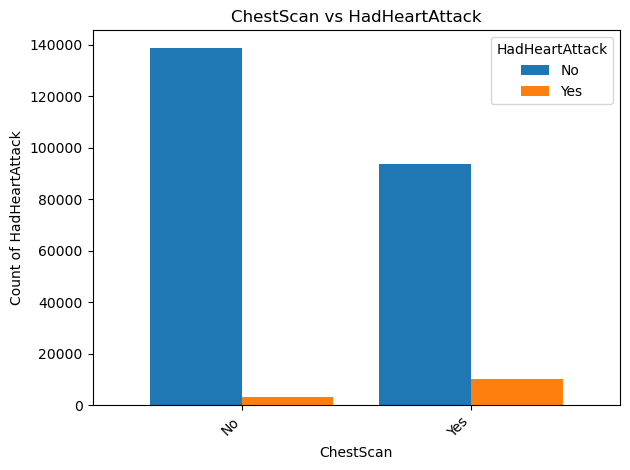

<Figure size 2000x600 with 0 Axes>

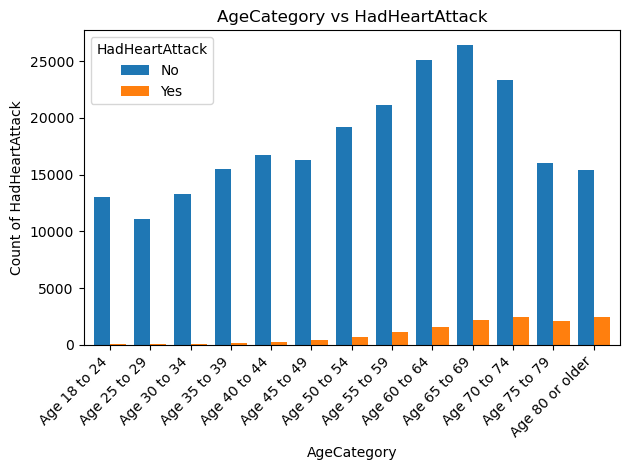

<Figure size 2000x600 with 0 Axes>

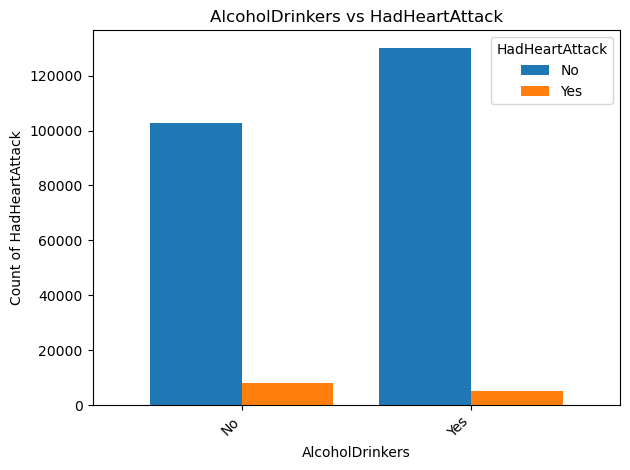

<Figure size 2000x600 with 0 Axes>

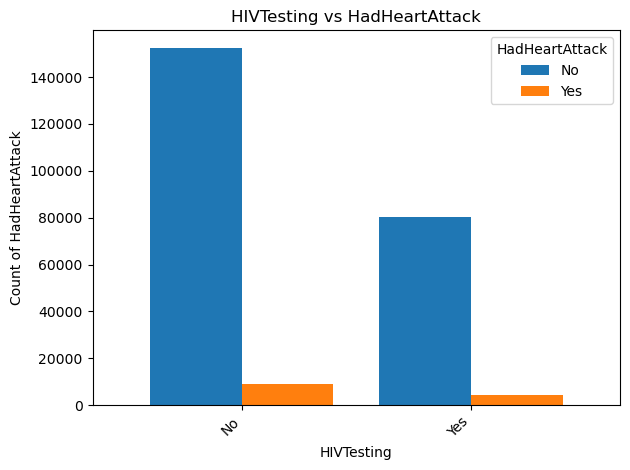

<Figure size 2000x600 with 0 Axes>

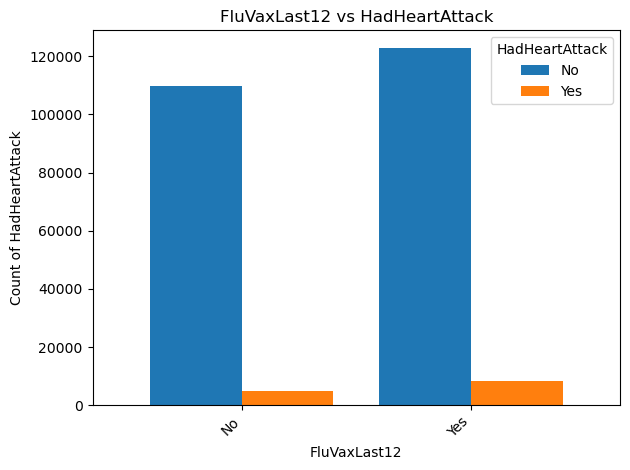

<Figure size 2000x600 with 0 Axes>

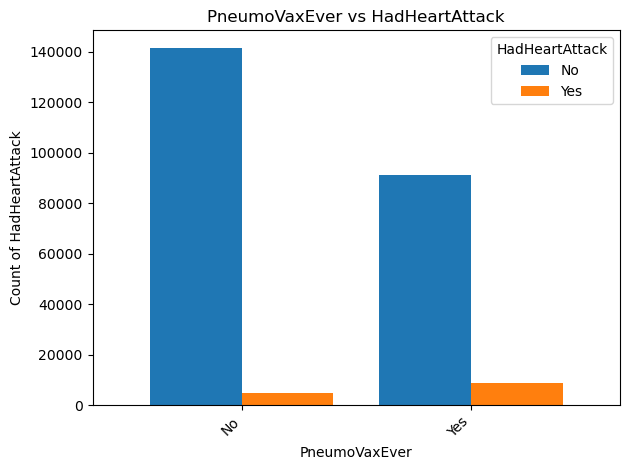

<Figure size 2000x600 with 0 Axes>

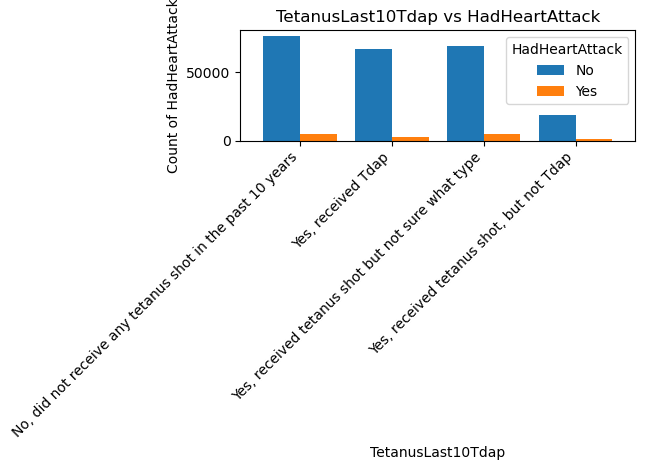

<Figure size 2000x600 with 0 Axes>

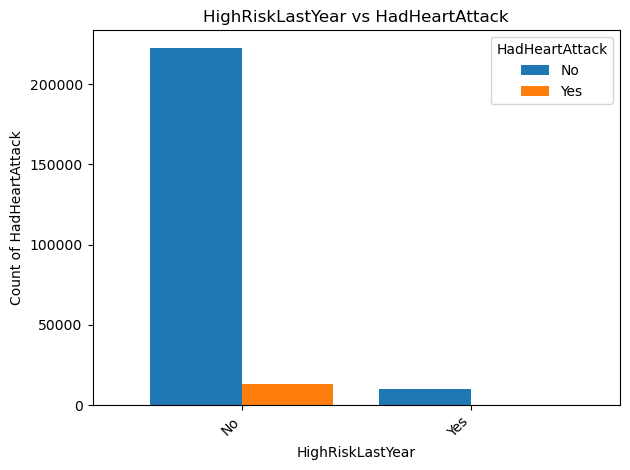

<Figure size 2000x600 with 0 Axes>

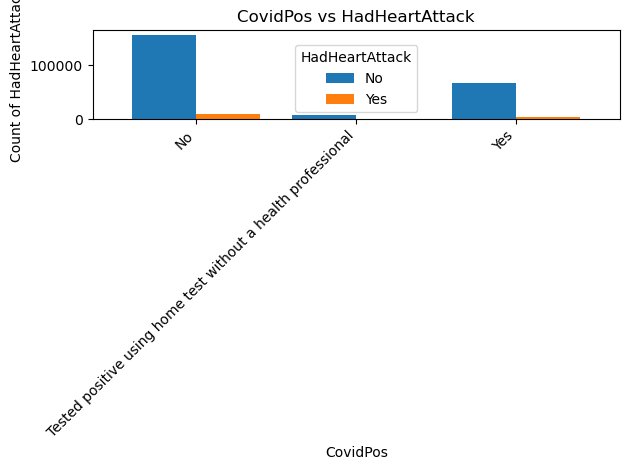

<Figure size 2000x600 with 0 Axes>

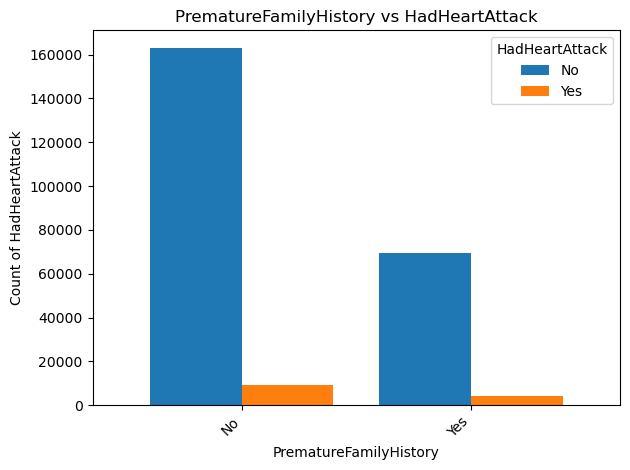

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter categorical features based on their data type
categorical_features = df.select_dtypes(include=['object', 'category']).columns

# Plotting each categorical feature with respect to 'HadHeartAttack'
for feature in categorical_features:
    plt.figure(figsize=(20, 6))
    
    # Create a crosstab of 'HadHeartAttack' counts for each category of the feature
    crosstab = pd.crosstab(df[feature], df['HadHeartAttack'], normalize=False)
    
    # Plot the crosstab result
    crosstab.plot(kind='bar', stacked=False, width=0.8)
    
    # Set the title, labels, and legend
    plt.title(f"{feature} vs HadHeartAttack")
    plt.xlabel(feature)
    plt.ylabel("Count of HadHeartAttack")
    plt.xticks(rotation=45, ha='right')
    plt.legend(title="HadHeartAttack", labels=["No", "Yes"])
    
    # Show the plot
    plt.tight_layout()
    plt.show()


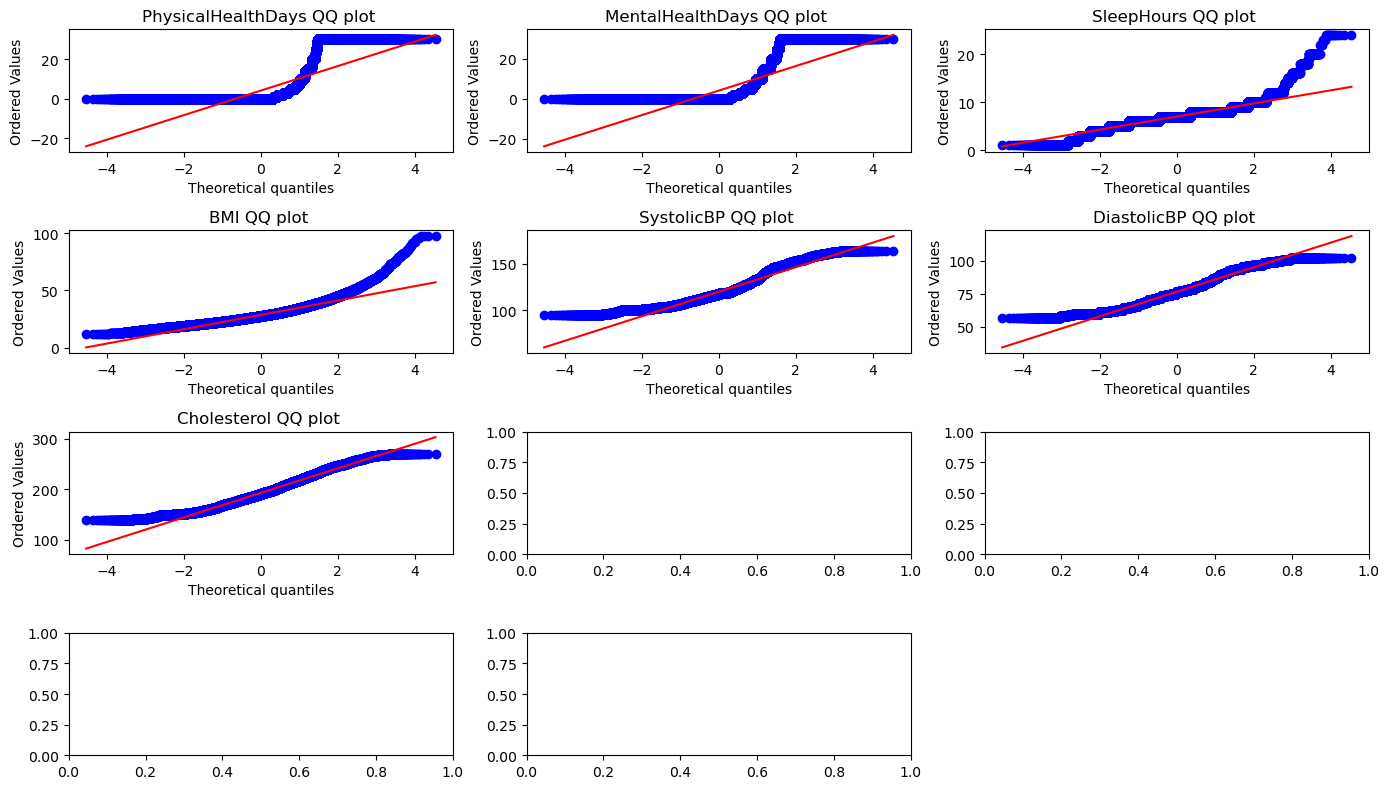

In [27]:
import matplotlib.pyplot as plt
from scipy import stats as st
fig,axes = plt.subplots(nrows = 4, ncols = 3, figsize = (14,8))
axes = axes.flatten()
for i,col in enumerate(num_features.columns):
    st.probplot(num_features[col], dist='norm', plot = axes[i])
    axes[i].set_title('{} QQ plot '.format(col))
fig.delaxes(axes[-1])
fig.tight_layout()
plt.show()

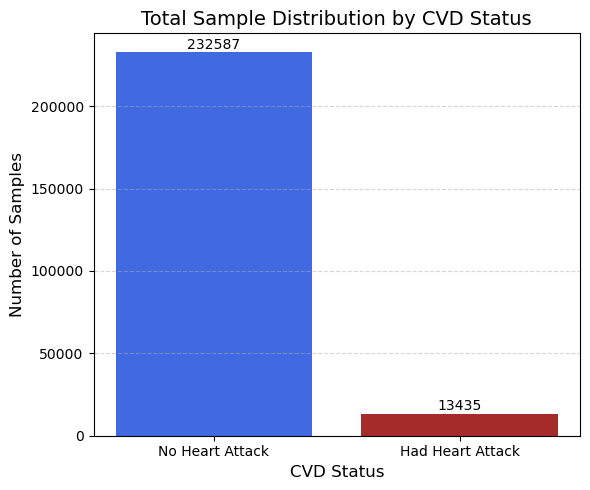

Class Distribution (No Split):
HadHeartAttack
No     232587
Yes     13435
Name: count, dtype: int64


In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your dataframe is already loaded as `df`
# df = pd.read_csv('your_dataset.csv')  # Uncomment if you're loading from file

# Define the target column
target_col = 'HadHeartAttack'  # Replace with your actual target column name

# Count the number of samples per class
class_counts = df[target_col].value_counts().sort_index()

# Create readable class labels
labels = ['No Heart Attack', 'Had Heart Attack'] if len(class_counts) == 2 else class_counts.index.astype(str)

# Plotting
plt.figure(figsize=(6, 5))
bars = plt.bar(labels, class_counts.values, color=['royalblue', 'brown'])

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 200, str(height), ha='center', va='bottom', fontsize=10)

# Customize plot
plt.xlabel('CVD Status', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Total Sample Distribution by CVD Status', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('cvd_total_distribution.png')
plt.show()

# Print the raw counts
print("Class Distribution (No Split):")
print(class_counts)


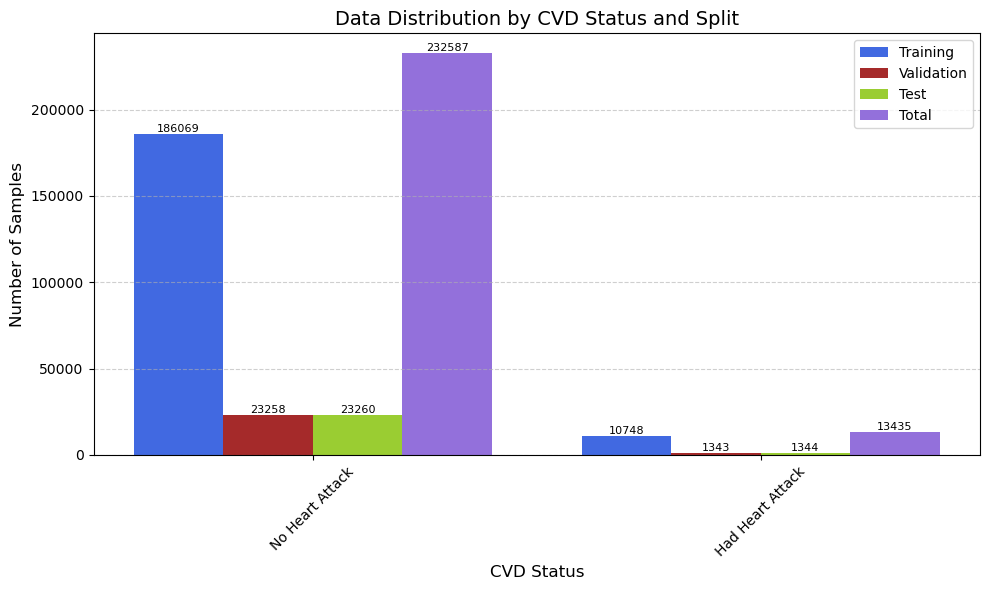

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
#df = pd.read_csv('your_dataset.csv')  # Replace with your actual file path

# Define the target column
target_col = 'HadHeartAttack'  # Change to your target column name

# Count samples per class
class_counts = df[target_col].value_counts().sort_index()

# Split by 80/10/10 rule
train_counts = (class_counts * 0.8).astype(int)
val_counts = (class_counts * 0.1).astype(int)
test_counts = class_counts - train_counts - val_counts
total_counts = class_counts

# Prepare DataFrame for plotting
labels = ['No Heart Attack', 'Had Heart Attack'] if len(class_counts) == 2 else class_counts.index.astype(str)
plot_df = pd.DataFrame({
    'CVD Status': labels,
    'Training': train_counts.values,
    'Validation': val_counts.values,
    'Test': test_counts.values,
    'Total': total_counts.values
})

# Plotting setup
bar_width = 0.2
r1 = np.arange(len(plot_df))
r2 = r1 + bar_width
r3 = r2 + bar_width
r4 = r3 + bar_width

plt.figure(figsize=(10, 6))

# Plot bars
bars_train = plt.bar(r1, plot_df['Training'], width=bar_width, color='royalblue', label='Training')
bars_val = plt.bar(r2, plot_df['Validation'], width=bar_width, color='brown', label='Validation')
bars_test = plt.bar(r3, plot_df['Test'], width=bar_width, color='yellowgreen', label='Test')
bars_total = plt.bar(r4, plot_df['Total'], width=bar_width, color='mediumpurple', label='Total')

# Add value labels on top of bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 10, str(height), ha='center', va='bottom', fontsize=8)

add_labels(bars_train)
add_labels(bars_val)
add_labels(bars_test)
add_labels(bars_total)

# Customize plot
plt.xlabel('CVD Status', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Data Distribution by CVD Status and Split', fontsize=14)
plt.xticks(r1 + 1.5 * bar_width, plot_df['CVD Status'], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('data_split.png')
plt.show()


In [30]:
from sklearn.preprocessing import LabelEncoder

# Assuming 'target' is your target variable (HadHeartAttack)
target_column = 'HadHeartAttack'

# Get numerical columns from the dataset
numerical_cols = df.select_dtypes(include=[np.number]).columns

# Convert categorical columns to numeric using Label Encoding (if any)
categorical_cols = df.select_dtypes(include=['object']).columns
label_encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

# Loop through each numerical feature and calculate its correlation with the target
correlations = {}
for col in numerical_cols:
    if col != target_column:  # Skip the target variable itself
        corr_value = df[col].corr(df[target_column])
        correlations[col] = corr_value

# Display correlations
for feature, corr in correlations.items():
    print(f"Correlation between {feature} and {target_column}: {corr}")


Correlation between PhysicalHealthDays and HadHeartAttack: 0.1334195128842576
Correlation between MentalHealthDays and HadHeartAttack: 0.025891963052166053
Correlation between SleepHours and HadHeartAttack: 0.003630922789503173
Correlation between BMI and HadHeartAttack: 0.030413481105606783
Correlation between SystolicBP and HadHeartAttack: 0.1884509700967526
Correlation between DiastolicBP and HadHeartAttack: 0.17655167533559482
Correlation between Cholesterol and HadHeartAttack: 0.16737127968918858


In [31]:
# Assuming the target variable is 'target'
class_distribution = df['HadHeartAttack'].value_counts()

# Display class distribution
print("Class Distribution:\n", class_distribution)


Class Distribution:
 HadHeartAttack
0    232587
1     13435
Name: count, dtype: int64


the dataset has a much larger number of samples for Class 0 (No Heart Attack) compared to Class 1 (Had Heart Attack). This is a typical case of class imbalance, where one class (in this case, the majority class, 0) outnumbers the other class (the minority class, 1) significantly.

To treat data imbalance, we can use the 17:1 method, which splits the majority class (Class 0) into 17 smaller, roughly equal subsets. This method helps manage class imbalance by creating more balanced datasets for model training or testing. It is useful for cross-validation, where different subsets are used for training and evaluation, thereby improving model robustness. Additionally, it helps manage large datasets by working with smaller, more manageable samples, making it efficient for experimentation and model testing.

In [32]:
import pandas as pd
import numpy as np

# Assuming the dataset is already loaded into 'df' and target column is 'target'

# Filter only class 0
class_0 = df[df['HadHeartAttack'] == 0]

# Calculate the size of each sample
sample_size = len(class_0) // 17

# Split class 0 into 17 subsets
samples = []
for i in range(17):
    start_idx = i * sample_size
    end_idx = (i + 1) * sample_size if i < 16 else len(class_0)  # Include remaining rows in the last sample
    samples.append(class_0.iloc[start_idx:end_idx])

# Save each subset as a separate file (optional)
for idx, sample in enumerate(samples):
    filename = f'class_0_sample_{idx + 1}.csv'
    sample.to_csv(filename, index=False)
    print(f"Saved {filename} with {len(sample)} rows.")

# Verify the sizes of each subset
for idx, sample in enumerate(samples):
    print(f"Sample {idx + 1}: {len(sample)} rows")


Saved class_0_sample_1.csv with 13681 rows.
Saved class_0_sample_2.csv with 13681 rows.
Saved class_0_sample_3.csv with 13681 rows.
Saved class_0_sample_4.csv with 13681 rows.
Saved class_0_sample_5.csv with 13681 rows.
Saved class_0_sample_6.csv with 13681 rows.
Saved class_0_sample_7.csv with 13681 rows.
Saved class_0_sample_8.csv with 13681 rows.
Saved class_0_sample_9.csv with 13681 rows.
Saved class_0_sample_10.csv with 13681 rows.
Saved class_0_sample_11.csv with 13681 rows.
Saved class_0_sample_12.csv with 13681 rows.
Saved class_0_sample_13.csv with 13681 rows.
Saved class_0_sample_14.csv with 13681 rows.
Saved class_0_sample_15.csv with 13681 rows.
Saved class_0_sample_16.csv with 13681 rows.
Saved class_0_sample_17.csv with 13691 rows.
Sample 1: 13681 rows
Sample 2: 13681 rows
Sample 3: 13681 rows
Sample 4: 13681 rows
Sample 5: 13681 rows
Sample 6: 13681 rows
Sample 7: 13681 rows
Sample 8: 13681 rows
Sample 9: 13681 rows
Sample 10: 13681 rows
Sample 11: 13681 rows
Sample 12: 

In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

# Assuming the dataset is already loaded into 'df' and the target column is 'HadHeartAttack'
target_col = "HadHeartAttack"  # Replace with the correct target column name

# Separate class 0 and class 1
class_0 = df[df[target_col] == 0]
class_1 = df[df[target_col] == 1]

# Calculate the size of each sample
sample_size = len(class_0) // 17

# Split class 0 into 17 subsets
samples = []
for i in range(17):
    start_idx = i * sample_size
    end_idx = (i + 1) * sample_size if i < 16 else len(class_0)
    samples.append(class_0.iloc[start_idx:end_idx])

# Initialize results list to store evaluation metrics
results = []

# Loop through each class 0 sample
for idx, sample in enumerate(samples):
    print(f"Processing sample {idx + 1}...")
    
    # Merge class 1 with the current class 0 sample
    merged_data = pd.concat([sample, class_1])
    
    # Shuffle the merged dataset
    merged_data = merged_data.sample(frac=1, random_state=42).reset_index(drop=True)
    
    # Save the merged dataset to a CSV file
    merged_filename = f'merged_dataset_sample_{idx + 1}.csv'
    merged_data.to_csv(merged_filename, index=False)
    print(f"Saved merged dataset: {merged_filename}")
    
    # Split features and target
    x = merged_data.drop(columns=[target_col])
    y = merged_data[target_col]
    
    # Encode categorical variables using Label Encoding
    for col in x.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        x[col] = le.fit_transform(x[col])
    
    # Ensure all transformations maintain the same length
    x = x.reset_index(drop=True)
    y = y.reset_index(drop=True)
    
    # Split into train and test sets (e.g., 80/20 split)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
    
    # Train a simple model (e.g., Logistic Regression)
    model = LogisticRegression(random_state=42, max_iter=1000)  # Increased max_iter for convergence
    model.fit(x_train, y_train)
    
    # Evaluate the model
    y_pred = model.predict(x_test)
    
    # Store the metrics
    metrics = {
        'sample': idx + 1,
        'accuracy': round(accuracy_score(y_test, y_pred), 2),
        'precision': round(precision_score(y_test, y_pred), 2),
        'recall': round(recall_score(y_test, y_pred), 2),
        'f1_score': round(f1_score(y_test, y_pred), 2)
    }
    results.append(metrics)
    print(f"Sample {idx + 1}: Metrics {metrics}")

# Save results to a CSV file
results_df = pd.DataFrame(results)

# Ensure the table is formatted to two decimal places for display
results_df = results_df.round(2)

# Save the formatted results to a CSV file
results_df.to_csv('model_results.csv', index=False)

print("Saved model evaluation results to 'model_results.csv'.")


Processing sample 1...
Saved merged dataset: merged_dataset_sample_1.csv
Sample 1: Metrics {'sample': 1, 'accuracy': 0.78, 'precision': 0.81, 'recall': 0.72, 'f1_score': 0.77}
Processing sample 2...
Saved merged dataset: merged_dataset_sample_2.csv
Sample 2: Metrics {'sample': 2, 'accuracy': 0.83, 'precision': 0.84, 'recall': 0.8, 'f1_score': 0.82}
Processing sample 3...
Saved merged dataset: merged_dataset_sample_3.csv
Sample 3: Metrics {'sample': 3, 'accuracy': 0.77, 'precision': 0.8, 'recall': 0.72, 'f1_score': 0.76}
Processing sample 4...
Saved merged dataset: merged_dataset_sample_4.csv
Sample 4: Metrics {'sample': 4, 'accuracy': 0.81, 'precision': 0.83, 'recall': 0.76, 'f1_score': 0.8}
Processing sample 5...
Saved merged dataset: merged_dataset_sample_5.csv
Sample 5: Metrics {'sample': 5, 'accuracy': 0.8, 'precision': 0.82, 'recall': 0.76, 'f1_score': 0.79}
Processing sample 6...
Saved merged dataset: merged_dataset_sample_6.csv
Sample 6: Metrics {'sample': 6, 'accuracy': 0.79, '

Process:
Dataset Splitting: The dataset is divided into two classes: Class 0 (non-heart attack) and Class 1 (heart attack). Class 0 is further split into 17 subsets of approximately equal size.

Merging and Shuffling: For each subset of Class 0, it is merged with all of Class 1. This creates a balanced dataset for each iteration, where the number of instances in each class is equal. After merging, the dataset is shuffled to ensure randomness.

Data Preprocessing: Categorical features in the dataset are encoded using Label Encoding, converting them into numeric values to prepare the data for machine learning.

Train-Test Split: The merged and preprocessed data is split into training and test sets (80% for training and 20% for testing) using the train_test_split function.

Model Training and Evaluation: A logistic regression model is trained on the training set and evaluated on the test set using standard classification metrics: accuracy, precision, recall, and F1-score.

Metrics Recording: The evaluation metrics for each subset are stored in a list and then saved as a CSV file (model_results.csv) for further analysis.

Output: For each subset, the merged dataset is saved as a CSV file, and the evaluation metrics are printed and saved for each iteration.
so i can use one of the sampled dataset for the model

In [36]:
df = pd.read_csv("merged_dataset_sample_1.csv")
df.head()

,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,HadHeartAttack,HadAngina,HadStroke,...,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,SystolicBP,DiastolicBP,Cholesterol,PrematureFamilyHistory
0,1,2,0,0,3,1,7,1,0,0,...,0,1,1,1,0,0,113,82,197,1
1,1,4,1,0,0,1,7,0,0,0,...,0,1,0,0,0,2,106,77,190,1
2,1,2,0,0,3,1,6,1,1,0,...,0,1,1,2,0,0,127,86,214,0
3,0,4,3,30,3,1,5,0,0,0,...,1,1,1,1,0,2,114,72,202,1
4,0,0,7,0,3,1,8,1,0,0,...,0,0,1,2,0,0,130,91,207,0


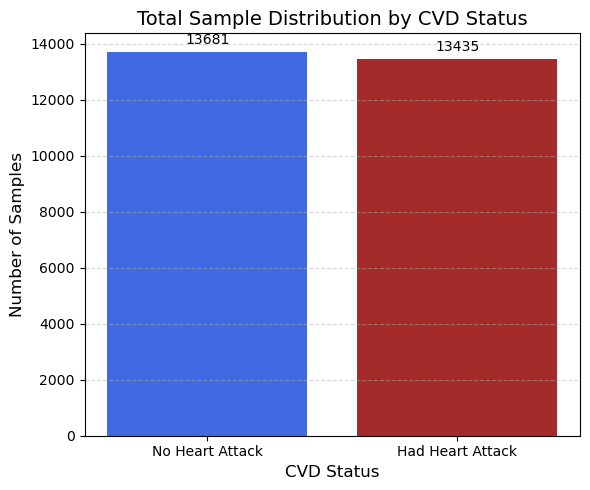

Class Distribution :
HadHeartAttack
0    13681
1    13435
Name: count, dtype: int64


In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your dataframe is already loaded as `df`
# df = pd.read_csv('your_dataset.csv')  # Uncomment if you're loading from file

# Define the target column
target_col = 'HadHeartAttack'  # Replace with your actual target column name

# Count the number of samples per class
class_counts = df[target_col].value_counts().sort_index()

# Create readable class labels
labels = ['No Heart Attack', 'Had Heart Attack'] if len(class_counts) == 2 else class_counts.index.astype(str)

# Plotting
plt.figure(figsize=(6, 5))
bars = plt.bar(labels, class_counts.values, color=['royalblue', 'brown'])

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 200, str(height), ha='center', va='bottom', fontsize=10)

# Customize plot
plt.xlabel('CVD Status', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Total Sample Distribution by CVD Status', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('cvd_total_distribution after Augmentation.png')
plt.show()

# Print the raw counts
print("Class Distribution :")
print(class_counts)


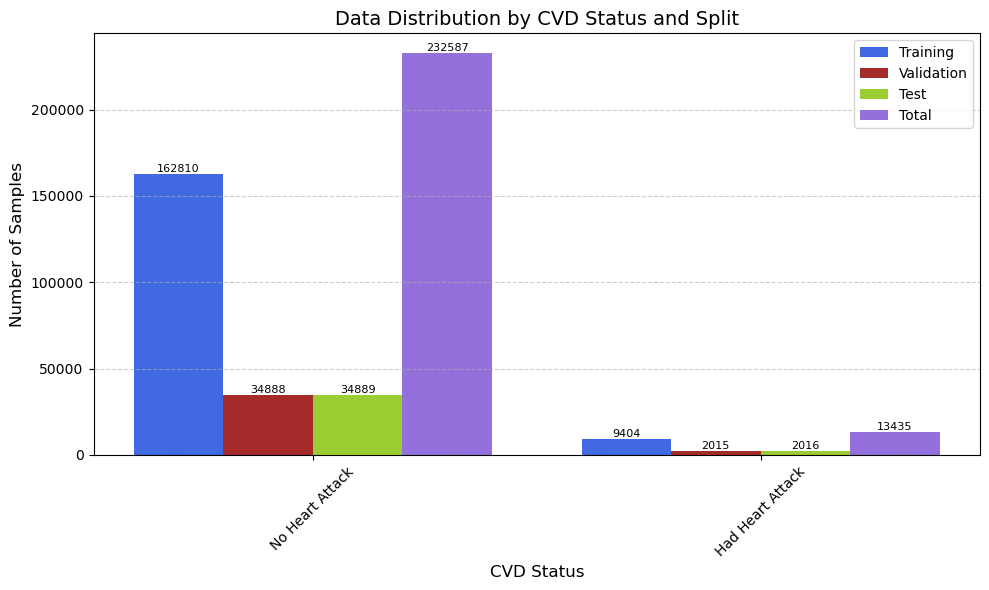

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
#df = pd.read_csv('your_dataset.csv')  # Replace with your actual file path

# Define the target column
target_col = 'HadHeartAttack'  # Change to your target column name

# Count samples per class
class_counts = df[target_col].value_counts().sort_index()

# Split by 80/10/10 rule
train_counts = (class_counts * 0.7).astype(int)
val_counts = (class_counts * 0.15).astype(int)
test_counts = class_counts - train_counts - val_counts
total_counts = class_counts

# Prepare DataFrame for plotting
labels = ['No Heart Attack', 'Had Heart Attack'] if len(class_counts) == 2 else class_counts.index.astype(str)
plot_df = pd.DataFrame({
    'CVD Status': labels,
    'Training': train_counts.values,
    'Validation': val_counts.values,
    'Test': test_counts.values,
    'Total': total_counts.values
})

# Plotting setup
bar_width = 0.2
r1 = np.arange(len(plot_df))
r2 = r1 + bar_width
r3 = r2 + bar_width
r4 = r3 + bar_width

plt.figure(figsize=(10, 6))

# Plot bars
bars_train = plt.bar(r1, plot_df['Training'], width=bar_width, color='royalblue', label='Training')
bars_val = plt.bar(r2, plot_df['Validation'], width=bar_width, color='brown', label='Validation')
bars_test = plt.bar(r3, plot_df['Test'], width=bar_width, color='yellowgreen', label='Test')
bars_total = plt.bar(r4, plot_df['Total'], width=bar_width, color='mediumpurple', label='Total')

# Add value labels on top of bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 10, str(height), ha='center', va='bottom', fontsize=8)

add_labels(bars_train)
add_labels(bars_val)
add_labels(bars_test)
add_labels(bars_total)

# Customize plot
plt.xlabel('CVD Status', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Data Distribution by CVD Status and Split', fontsize=14)
plt.xticks(r1 + 1.5 * bar_width, plot_df['CVD Status'], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('data_split.png')
plt.show()


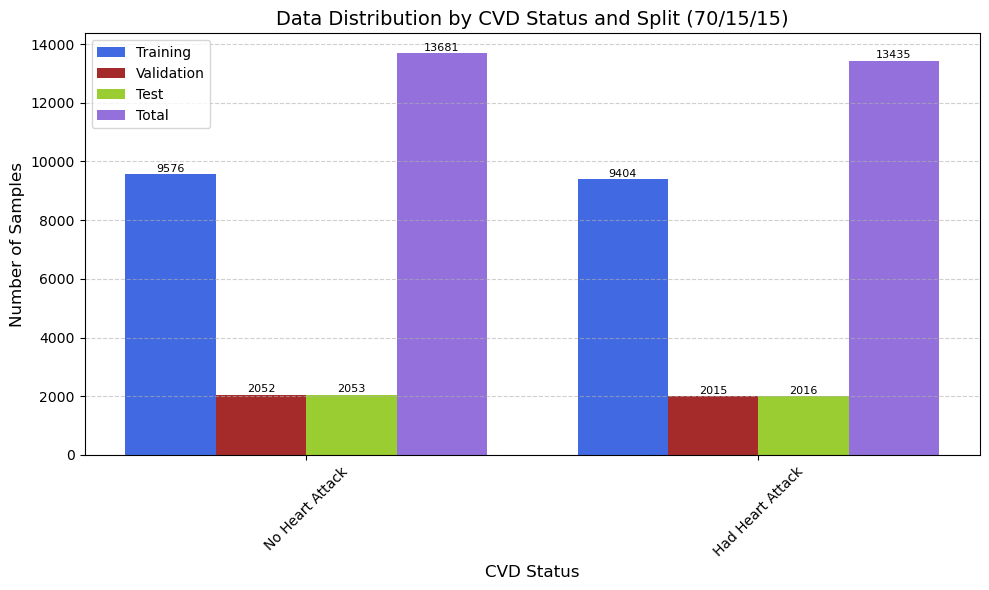

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
# df = pd.read_csv('your_dataset.csv')  # Replace with your actual file path

# Define the target column
target_col = 'HadHeartAttack'  # Change to your target column name

# Count samples per class
class_counts = df[target_col].value_counts().sort_index()

# Split by 70/15/15 rule
train_counts = (class_counts * 0.7).astype(int)
val_counts = (class_counts * 0.15).astype(int)
test_counts = class_counts - train_counts - val_counts
total_counts = class_counts

# Prepare DataFrame for plotting
labels = ['No Heart Attack', 'Had Heart Attack'] if len(class_counts) == 2 else class_counts.index.astype(str)
plot_df = pd.DataFrame({
    'CVD Status': labels,
    'Training': train_counts.values,
    'Validation': val_counts.values,
    'Test': test_counts.values,
    'Total': total_counts.values
})

# Plotting setup
bar_width = 0.2
r1 = np.arange(len(plot_df))
r2 = r1 + bar_width
r3 = r2 + bar_width
r4 = r3 + bar_width

plt.figure(figsize=(10, 6))

# Plot bars
bars_train = plt.bar(r1, plot_df['Training'], width=bar_width, color='royalblue', label='Training')
bars_val = plt.bar(r2, plot_df['Validation'], width=bar_width, color='brown', label='Validation')
bars_test = plt.bar(r3, plot_df['Test'], width=bar_width, color='yellowgreen', label='Test')
bars_total = plt.bar(r4, plot_df['Total'], width=bar_width, color='mediumpurple', label='Total')

# Add value labels on top of bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 10, str(height), ha='center', va='bottom', fontsize=8)

add_labels(bars_train)
add_labels(bars_val)
add_labels(bars_test)
add_labels(bars_total)

# Customize plot
plt.xlabel('CVD Status', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Data Distribution by CVD Status and Split (70/15/15)', fontsize=14)
plt.xticks(r1 + 1.5 * bar_width, plot_df['CVD Status'], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('data_split_70_15_15.png')
plt.show()
